# GPTQ / OBQ：基于 Hessian 的误差补偿量化

> **PTQ 教学 demo 系列 · 02 / 13**
> 配套博客：[《GPTQ 与 OBQC：基于 Hessian 的二阶权重量化》](https://lrypcy.github.io/2026/08/24/ptq-02-gptq/)（《大模型 PTQ 量化》深度系列 · 第 2 篇）

**一段话原理**：GPTQ（Frantar et al., 2022, arXiv:2210.17323）把「量化一层权重」形式化为逐层重建问题 $\min_{\hat W}\|WX-\hat W X\|_F^2$：量化扰动 $\delta$ 的代价由校准激活的二阶矩——Hessian $H=2XX^\top$——构成的二次型 $\tfrac12\delta H\delta^\top$ 精确刻画。用 Lagrange 乘子法可解出闭式补偿规则：把第 $q$ 个权重舍入到格点产生的误差 $c$，按 $H^{-1}$ 第 $q$ 列的比例摊给所有未量化权重（$w_{j>q}\mathrel{+}=\frac{c}{[H^{-1}]_{qq}}\,[H^{-1}]_{jq}$），即「量化一列、修复一行」。其前身 OBQ（arXiv:2208.11580）的贪心更新代价高达 $O(d_{col}^3)$；GPTQ 以固定量化顺序、Lazy-Batch 批更新与 Cholesky 分解三个改进把它推到 175B 规模。本 demo 用纯 numpy 在 toy 规模合成数据上从零走通这条数学链路，并验证补偿版误差显著低于无补偿的 RTN 基线。

## 第 1 步 · 环境与量化工具箱

这步在做什么：导入 numpy 与 matplotlib 并固定随机种子；实现贯穿全篇的基础设施——分组对称量化原语（每行每 group_size 个输入通道共享一个 scale）、RTN 基线、以及 layer-wise 相对误差指标 $\|(W-\hat W)X\|_F^2/\|WX\|_F^2$。RTN 与 GPTQ 之后共用同一套量化网格与评分标准，唯一区别就是有没有误差补偿。

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

SEED = 0                    # 全局随机种子: 结果完全可复现
D_ROW, D_COL = 64, 256      # 权重形状 (d_out, d_in)
N_CAL, N_EVAL = 512, 512    # 校准 / 留出激活样本数(均 <= d_col 的 2 倍, toy 规模)
GROUP_SIZE = 128            # 每 128 个输入通道共享一个 scale
DAMP_FRAC = 0.01            # dampening: lambda = H 对角均值的 1%
BITS_LIST = (4, 3, 2)


def group_scales_row(w, group_size, qmax):
    """单行权重的分组对称 scale: 组内共享 scale = max|w_group| / qmax."""
    sc = np.empty(w.shape[0])
    for s in range(0, w.shape[0], group_size):
        sl = slice(s, min(s + group_size, w.shape[0]))
        sc[sl] = max(np.abs(w[sl]).max() / qmax, 1e-12)
    return sc


def quant_row(w, sc, qmax):
    """对称量化 + 反量化: q = clip(round(w/s), +-qmax), 再乘回 scale."""
    return np.clip(np.round(w / sc), -qmax, qmax) * sc


def rtn_layer(W, bits, group_size):
    """RTN 基线: 同一量化网格直接取整, 零补偿."""
    qmax = 2 ** (bits - 1) - 1
    return np.stack([quant_row(W[i], group_scales_row(W[i], group_size, qmax), qmax)
                     for i in range(W.shape[0])])


def rel_mse(W, Wq, X):
    """layer-wise 目标函数本身: ||WX - WqX||_F^2 / ||WX||_F^2."""
    return float(np.linalg.norm((W - Wq) @ X) ** 2 / np.linalg.norm(W @ X) ** 2)

print("工具箱就绪:", [fn.__name__ for fn in (group_scales_row, quant_row, rtn_layer, rel_mse)])

工具箱就绪: ['group_scales_row', 'quant_row', 'rtn_layer', 'rel_mse']


## 第 2 步 · 合成数据 → Hessian $H=2XX^\top$ 的构造与求逆

这步在做什么：构造 toy 规模合成数据——激活 $X$ 来自特征值跨 3 个数量级的病态协方差（模拟 LLM 激活的低秩主导结构），权重 $W$ 含少数幅值 ×15 的 outlier 列；随后按定义构造本方法的核心对象 Hessian $H=2XX^\top$，加阻尼 $\lambda I$ 后做 Cholesky 分解得 $H^{-1}=L^{-\top}L^{-1}$。阻尼的作用看右图的谱就明白：512 条样本估计 256 维的 $H$ 噪声不小，最小特征值几乎贴地，$\lambda$ 把它抬起，分解才数值稳定。

H 形状 (256, 256), cond(H_raw)=4.15e+03 -> cond(H+lambda*I)=6.74e+02
验证 M @ H = I: max|M@H - I| = 3.4e-14


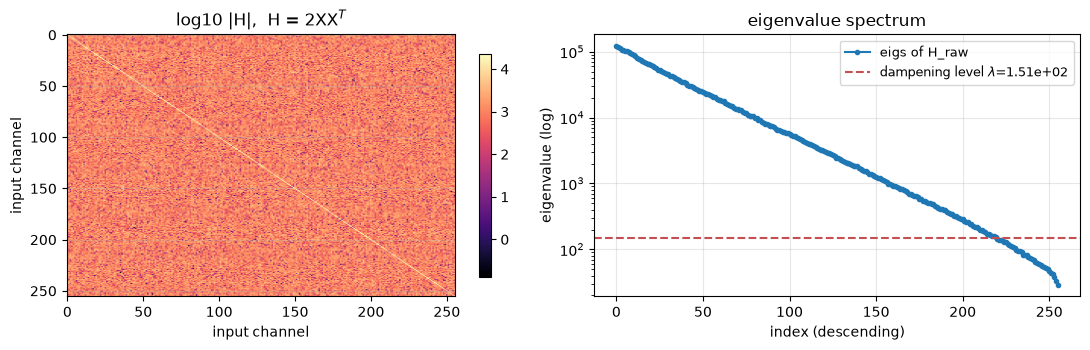

In [2]:
rng = np.random.default_rng(SEED)

# --- 合成激活: 病态协方差(特征值跨 3 个数量级) ---
u, _ = np.linalg.qr(rng.normal(size=(D_COL, D_COL)))      # 随机正交基
eigvals = np.geomspace(100.0, 0.1, D_COL)
cov = (u * eigvals) @ u.T
X_cal = rng.multivariate_normal(np.zeros(D_COL), cov, size=N_CAL).T     # (d_col, n_cal)
X_eval = rng.multivariate_normal(np.zeros(D_COL), cov, size=N_EVAL).T   # (d_col, n_eval)

# --- 合成权重: 5/256 列幅值 x15, 复刻 LLM 权重的重尾结构 ---
W = rng.normal(size=(D_ROW, D_COL)) * 0.02
W[:, rng.choice(D_COL, 5, replace=False)] *= 15.0

# --- 核心对象: H = 2XX^T -> 阻尼 -> Cholesky 求逆 ---
H_raw = 2.0 * (X_cal @ X_cal.T)                           # (d_col, d_col)
lam = DAMP_FRAC * np.mean(np.diag(H_raw))                 # lambda = 1% 对角均值
H = H_raw + lam * np.eye(D_COL)
L = np.linalg.cholesky(H)                                 # H = L L^T
Li = np.linalg.inv(L)
M = Li.T @ Li                                             # M = H^-1 = L^-T L^-1

print(f"H 形状 {H.shape}, cond(H_raw)={np.linalg.cond(H_raw):.2e}"
      f" -> cond(H+lambda*I)={np.linalg.cond(H):.2e}")
print(f"验证 M @ H = I: max|M@H - I| = {np.abs(M @ H - np.eye(D_COL)).max():.1e}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
im = ax[0].imshow(np.log10(np.abs(H_raw) + 1e-12), cmap="magma", aspect="auto")
ax[0].set_title("log10 |H|,  H = 2XX$^T$")
ax[0].set_xlabel("input channel")
ax[0].set_ylabel("input channel")
fig.colorbar(im, ax=ax[0], shrink=0.85)
ev = np.linalg.eigvalsh(H_raw)[::-1]
ax[1].semilogy(ev, "o-", ms=3, label="eigs of H_raw")
ax[1].axhline(lam, color="#C44E52", ls="--", label=f"dampening level $\\lambda$={lam:.2e}")
ax[1].set_title("eigenvalue spectrum")
ax[1].set_xlabel("index (descending)")
ax[1].set_ylabel("eigenvalue (log)")
ax[1].legend(fontsize=9)
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 第 3 步 · 无补偿基线 RTN

这步在做什么：在同一套分组对称网格上把 $W$ 直接舍入到最近格点，记录 INT4/3/2 三个位宽下的输出相对误差。RTN 隐含假设 Hessian 是对角阵——每个权重独立、互不影响；而真实 $H$ 有强非对角耦合，这正是 RTN 在低比特崩溃的原因，也是下一步补偿要利用的信息。

In [3]:
rtn_mse = {}
print(f"{'bits':>4} {'MSE@cal':>12} {'MSE@eval':>12}")
for b in BITS_LIST:
    Wr = rtn_layer(W, b, GROUP_SIZE)
    rtn_mse[b] = {"cal": rel_mse(W, Wr, X_cal), "eval": rel_mse(W, Wr, X_eval)}
    print(f"{b:>4} {rtn_mse[b]['cal']:>12.3e} {rtn_mse[b]['eval']:>12.3e}")

bits      MSE@cal     MSE@eval
   4    8.762e-02    8.873e-02
   3    1.664e-01    1.681e-01
   2    2.934e-01    2.941e-01


## 第 4 步 · 方法核心：逐列量化 + 截断误差补偿

这步在做什么：实现 OBQ/GPTQ 的核心循环（固定顺序版）——对每一行从左到右逐列处理：先把**当前值** $w_q$ 舍入到格点，记误差 $c=\hat w_q-w_q$，立刻按闭式解把 $c$ 摊给右侧所有未量化列：

$$w_{q+1:}\;\leftarrow\;w_{q+1:}+\frac{c}{[H^{-1}]_{qq}}\,[H^{-1}]_{q+1:,\,q}$$

两个必踩的坑：(a) **索引位移**——补偿必须从 $q+1$ 开始截断（左侧已冻结，且 $w_q$ 自己不能再动），误写成整列 $M[q{:},\,q]$ 会把刚落格点的列又推离网格；(b) 补偿方向是 $H^{-1}$ 的列，不是 Cholesky 因子 $L^{-1}$ 的列。跑完先做 sanity check：补偿版误差必须全面低于 RTN。

sanity check passed: GPTQ eval MSE < RTN @ INT4/3/2

bits     RTN@eval    GPTQ@eval       降低
   4    8.873e-02    7.639e-02    13.9%
   3    1.681e-01    1.566e-01     6.8%
   2    2.941e-01    2.860e-01     2.8%

未量化区间的平均绝对位移: 1.34e-03


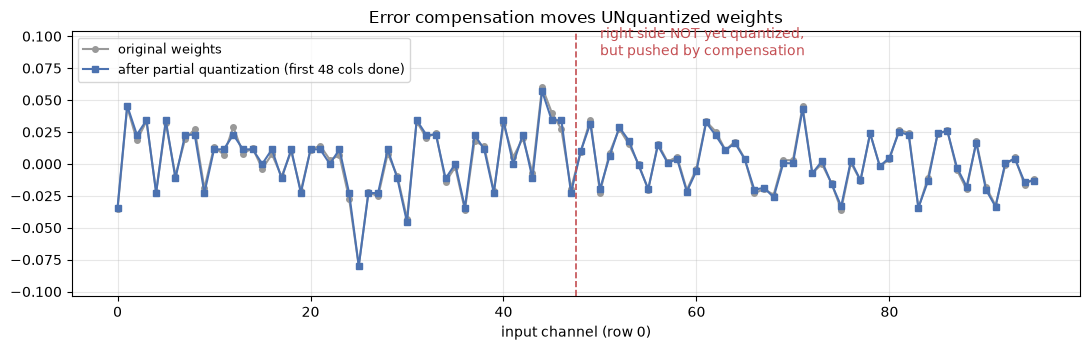

In [4]:
def gptq_step(W, M, bits, group_size):
    """GPTQ 核心循环(逐步版): 量化一列 -> 按 H^-1 的列把误差反传给未量化列."""
    qmax = 2 ** (bits - 1) - 1
    d_row, d_col = W.shape
    scales = np.stack([group_scales_row(W[i], group_size, qmax)    # scale 固定自原始 W
                       for i in range(d_row)])
    Wq = W.copy()
    for i in range(d_row):
        w, sc = Wq[i], scales[i]
        for q in range(d_col):
            w_hat = np.clip(np.round(w[q] / sc[q]), -qmax, qmax) * sc[q]
            c = w_hat - w[q]            # 本列舍入误差 c = w_hat_q - w_q
            w[q] = w_hat                # 先落格点
            if q + 1 < d_col:
                # 截断补偿(注意索引位移: 从 q+1 起, 不碰已量化的 w[:q+1])
                w[q + 1:] += (c / M[q, q]) * M[q + 1:, q]
    return Wq


gptq_mse = {}
for b in BITS_LIST:
    Wg = gptq_step(W, M, b, GROUP_SIZE)
    gptq_mse[b] = {"cal": rel_mse(W, Wg, X_cal), "eval": rel_mse(W, Wg, X_eval)}

# --- sanity check: 补偿版必须在全部位宽下优于无补偿 RTN ---
assert all(gptq_mse[b]["eval"] < rtn_mse[b]["eval"] for b in BITS_LIST), "GPTQ 应严格优于 RTN!"
print("sanity check passed: GPTQ eval MSE < RTN @ INT4/3/2")

print(f"\n{'bits':>4} {'RTN@eval':>12} {'GPTQ@eval':>12} {'降低':>8}")
for b in BITS_LIST:
    r, g = rtn_mse[b]["eval"], gptq_mse[b]["eval"]
    print(f"{b:>4} {r:>12.3e} {g:>12.3e} {(1 - g / r) * 100:>7.1f}%")

# --- 可视化补偿效应: 只量化行 0 的前 K 列, 观察右侧未量化列被推动 ---
K, qmax_d = 48, 2 ** (4 - 1) - 1
sc0 = group_scales_row(W[0], GROUP_SIZE, qmax_d)
w_orig = W[0].copy()
w_part = w_orig.copy()
for q in range(K):
    w_hat = np.clip(np.round(w_part[q] / sc0[q]), -qmax_d, qmax_d) * sc0[q]
    c = w_hat - w_part[q]
    w_part[q] = w_hat
    w_part[q + 1:] += (c / M[q, q]) * M[q + 1:, q]

print(f"\n未量化区间的平均绝对位移: "
      f"{np.abs(w_part[K:] - w_orig[K:]).mean():.2e}")

fig, ax = plt.subplots(figsize=(11, 3.6))
idx = np.arange(96)
ax.plot(idx, w_orig[:96], "o-", ms=4, color="#999999", label="original weights")
ax.plot(idx, w_part[:96], "s-", ms=4, color="#4C72B0",
        label="after partial quantization (first 48 cols done)")
ymax = np.abs(w_orig[:96]).max() * 1.3
ax.axvline(K - 0.5, color="#C44E52", ls="--", lw=1.2)
ax.text(K + 2, ymax * 0.82, "right side NOT yet quantized,\nbut pushed by compensation", color="#C44E52", fontsize=10)
ax.set_ylim(-ymax, ymax)
ax.set_xlabel("input channel (row 0)")
ax.set_title("Error compensation moves UNquantized weights")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 第 5 步 · Lazy-Batch 批更新与总对比

这步在做什么：把逐步补偿改写为论文的 Lazy-Batch 形式——批内只把补偿累进缓冲 $\Delta\mathrel{+}=\frac{c}{[H^{-1}]_{qq}}\,d$，每 $B$ 列才一次性写回权重。由于所有更新都是 $H^{-1}$ 固定列的线性叠加，它与逐步版**数学严格等价**（数值上至多差浮点求和顺序），但把对整行的写回次数从 $d_{col}$ 次降到 $d_{col}/B$ 次——GPU 上这正是带宽节省的数量级来源。最后汇总 RTN 对比 GPTQ 的全位宽结果。

bits=3: 逐步版 vs Lazy-Batch 最大权重点差 = 0.0e+00
两者 eval MSE 一致: 1.566e-01 vs 1.566e-01
toy CPU 耗时接近: 逐步 0.10s / lazy 0.07s —— 收益主要在 GPU 带宽而非本地循环



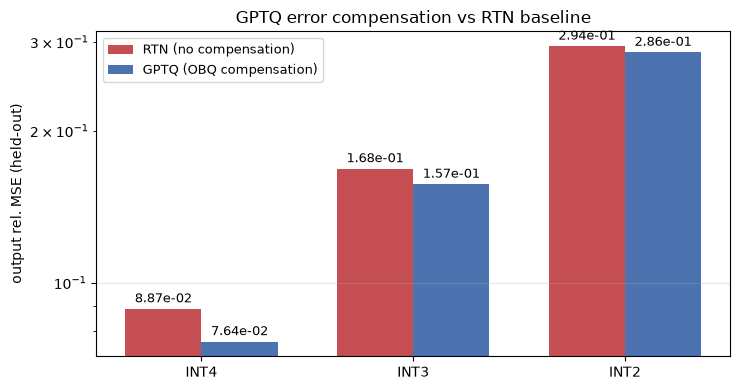

INT4: eval 相对 MSE 8.873e-02 -> 7.639e-02  (SNR 10.52 -> 11.17 dB)
INT3: eval 相对 MSE 1.681e-01 -> 1.566e-01  (SNR 7.74 -> 8.05 dB)
INT2: eval 相对 MSE 2.941e-01 -> 2.860e-01  (SNR 5.32 -> 5.44 dB)


In [5]:
def gptq_lazy_batch(W, M, bits, group_size, blocksize=64):
    """Lazy-Batch 版 GPTQ: 批内累积补偿 delta, 批边界一次性写回."""
    qmax = 2 ** (bits - 1) - 1
    d_row, d_col = W.shape
    scales = np.stack([group_scales_row(W[i], group_size, qmax) for i in range(d_row)])
    Wq = W.copy()
    for i in range(d_row):
        w, sc = Wq[i], scales[i]
        for s in range(0, d_col, blocksize):
            e = min(s + blocksize, d_col)
            blk = w[s:e].copy()              # 本批快照(已含上一批摊来的补偿)
            delta = np.zeros(d_col - s)      # 待应用的累计补偿
            for k in range(e - s):
                q = s + k
                w_cur = blk[k] + delta[k]
                w_hat = np.clip(np.round(w_cur / sc[q]), -qmax, qmax) * sc[q]
                c = w_hat - w_cur
                blk[k] = w_hat
                delta[k + 1:] += (c / M[q, q]) * M[q + 1:, q]
            w[s:e] = blk                     # 批内各列已全部落格点
            if e < d_col:
                w[e:] += delta[e - s:]       # 未消费的补偿一次写给后续列
    return Wq


b_check = 3
t0 = time.perf_counter(); Wg1 = gptq_step(W, M, b_check, GROUP_SIZE); t_step = time.perf_counter() - t0
t0 = time.perf_counter(); Wg2 = gptq_lazy_batch(W, M, b_check, GROUP_SIZE); t_lazy = time.perf_counter() - t0
print(f"bits={b_check}: 逐步版 vs Lazy-Batch 最大权重点差 = {np.abs(Wg1 - Wg2).max():.1e}")
print(f"两者 eval MSE 一致: {rel_mse(W, Wg1, X_eval):.3e} vs {rel_mse(W, Wg2, X_eval):.3e}")
print(f"toy CPU 耗时接近: 逐步 {t_step:.2f}s / lazy {t_lazy:.2f}s —— 收益主要在 GPU 带宽而非本地循环\n")

# --- 汇总: RTN vs GPTQ 全位宽柱状图(held-out 集) ---
x = np.arange(len(BITS_LIST))
rtn_vals = [rtn_mse[b]["eval"] for b in BITS_LIST]
gpt_vals = [gptq_mse[b]["eval"] for b in BITS_LIST]
fig, ax = plt.subplots(figsize=(7.5, 4))
wd = 0.36
ax.bar(x - wd / 2, rtn_vals, wd, label="RTN (no compensation)", color="#C44E52")
ax.bar(x + wd / 2, gpt_vals, wd, label="GPTQ (OBQ compensation)", color="#4C72B0")
for xi, (vr, vg) in enumerate(zip(rtn_vals, gpt_vals)):
    ax.text(xi - wd / 2, vr * 1.03, f"{vr:.2e}", ha="center", fontsize=9)
    ax.text(xi + wd / 2, vg * 1.03, f"{vg:.2e}", ha="center", fontsize=9)
ax.set_yscale("log")
ax.set_xticks(x, [f"INT{b}" for b in BITS_LIST])
ax.set_ylabel("output rel. MSE (held-out)")
ax.set_title("GPTQ error compensation vs RTN baseline")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

for b in BITS_LIST:
    snr_r = -10 * np.log10(rtn_mse[b]["eval"])
    snr_g = -10 * np.log10(gptq_mse[b]["eval"])
    print(f"INT{b}: eval 相对 MSE {rtn_mse[b]['eval']:.3e} -> {gptq_mse[b]['eval']:.3e}"
          f"  (SNR {snr_r:.2f} -> {snr_g:.2f} dB)")

## 结果解读与方法局限

**结果解读**（以下为 SEED=0 实测输出）：

- **补偿全面有效**。held-out 相对 MSE：INT4 从 RTN 的 8.873e-2 降到 7.639e-2（降约 14%，SNR 10.52 → 11.17 dB）；INT3 从 1.681e-1 降到 1.566e-1（降约 6.8%）；INT2 也有 2.8% 改善。sanity 断言确认每个位宽下补偿版都严格优于 RTN。
- **位宽越低补偿越力不从心**：相对改善从 INT4 的 14% 一路缩到 INT2 的 2.8%——2-bit 的舍入扰动已超出二次近似 $\Delta E\approx\tfrac12\delta H\delta^\top$ 的适用范围，与博客「GPTQ 安全区在 3–4 bit」的论述一致。
- **校准集与留出集误差基本持平**（INT4 GPTQ：7.469e-2 对比 7.639e-2）：说明补偿没有过拟合校准样本；但补偿上限受 Hessian 估计质量制约——配套实验 `run.py` 把校准样本加到 4096 条后，INT4 增益可到 35%（eval MSE 5.70e-2 对比 RTN 8.78e-2），印证博客 §7.2「校准依赖」的论断。
- **阻尼不可或缺**：第 2 步实测 cond(H) 约 4.15e3，加 λ 后降到 6.74e2；若样本数少于 $d_{col}$ 且不加阻尼，Cholesky 会直接失败（博客 §3.4 的「保险」叙述在本 toy 设定下就能复现）。
- **Lazy-Batch 严格等价**：两种写法的最大权重点差实测为 0，eval MSE 完全一致——它是纯工程优化，不改变数学；toy CPU 上耗时接近，收益要在 GPU 带宽上才兑现。

**方法局限**：

1. **内存墙**：$H\in\mathbb{R}^{d_{col}\times d_{col}}$，FP64 下 $d_{col}=12288$ 就要约 1.2 GB，Cholesky 为 $O(d_{col}^3)$，超宽模型（如 MoE expert 层）难以承受；
2. **校准依赖**：$H$ 完全来自校准激活分布，域偏移（C4 校准、代码场景部署）会让补偿方向失准；
3. **二阶近似边界**：2-bit 及以下的扰动超出泰勒展开收敛域，需 act_order、更细 group 乃至 QuIP#/AQLM 的旋转与码本路线救场；
4. **逐层独立假设**：忽略跨层误差传播，单层误差小时无害，低比特下层间累积会雪崩；
5. 本 demo 未实现 act_order 与 group scale 动态刷新（scale 固定自原始 $W$），属教学简化，不影响定性结论。